# P2.1 Project: Fake vs. Real Review Classification

We will build Machine Learning models to classify restaurant reviews as Fake or Real.

#### Install the required Python packages and spaCy language model:

In [1]:
import importlib.util

required_modules = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "nltk": "nltk",
    "spacy": "spacy",
    "spellchecker": "pyspellchecker",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "matplotlib": "matplotlib"
}

missing_modules = [
    package_name
    for module_name, package_name in required_modules.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_modules:
    raise ImportError(
        "Missing dependencies: " + ", ".join(missing_modules)
    )

print("All Python dependencies are installed.")

All Python dependencies are installed.


In [2]:
import spacy
import subprocess
import sys

if not spacy.util.is_package("en_core_web_sm"):
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
else:
    print("spaCy model en_core_web_sm is already installed.")

spaCy model en_core_web_sm is already installed.


#### Import libraries and initialize NLP tools

In [3]:
import pandas as pd
import numpy as np
import spacy

#### Upload and load the restaurant review dataset

In [4]:
from pathlib import Path

data_path = Path("restaurant_reviews-v2-1.xlsx")

if not data_path.exists():
    from google.colab import files
    files.upload()

df = pd.read_excel(data_path)
print(f"Loaded data from {data_path.resolve()}")

Loaded data from C:\Users\19492\Desktop\cs273\Project2.1\restaurant_reviews-v2-1.xlsx


#### Rename columns and keep the required dataset fields
The original dataset uses long column names. We rename them to shorter,
clearer names so that the review text and fake/real label are easier to use
in Python. The sentiment column is retained for reference but is not used
during model training because the project requires models to use only the
10 extracted linguistic features.

In [5]:
df = df.rename(columns={
    "Restaurant": "restaurant",
    "Review": "review",
    "Real=1/Fake=0": "label",
    "positive=1/negative=0": "sentiment"
})

df = df[["restaurant", "review", "label", "sentiment"]]
df = df.dropna(subset=["review", "label"])

df["review"] = df["review"].astype(str)
df["label"] = df["label"].astype(int)

print(df.shape)
print(df["label"].value_counts())
display(df.head())

(260, 4)
0    130
1    130
Name: label, dtype: int64


,restaurant,review,label,sentiment
0,Tikka Shack,Great food and great atmosphere! The chicken t...,0,1
1,Tikka Shack,I had heard good things about Tikka Shak so I ...,0,0
2,Tikka Shack,I was driving by tikka shack one day and decid...,0,0
3,Tikka Shack,Tikka Shack had the most modern and up-to-date...,0,1
4,India Palace\nIndian\nRestaurant,Today is the third time I've come to India Pal...,0,1


#### Define the names of the 10 required features

In [6]:
FEATURE_NAMES = [
    "AWL", "ASL", "NWO", "NVB", "NAJ",
    "NPV", "NST", "CDV", "NTP", "TPR"
]

print(FEATURE_NAMES)

['AWL', 'ASL', 'NWO', 'NVB', 'NAJ', 'NPV', 'NST', 'CDV', 'NTP', 'TPR']


Define functions for extracting the 10 required text features

In [7]:
def get_words(text):
    return re.findall(r"\b[A-Za-z]+\b", text)


def count_passive_voice(doc):
    passive_subjects = [
        token for token in doc
        if token.dep_ == "nsubjpass"
    ]

    passive_auxiliaries = [
        token for token in doc
        if token.dep_ == "auxpass"
    ]

    return max(
        len(passive_subjects),
        len(passive_auxiliaries)
    )


def count_typos(words):
    valid_words = [
        word.lower()
        for word in words
        if word.isalpha() and len(word) >= 3
    ]

    if len(valid_words) == 0:
        return 0

    return len(spell.unknown(valid_words))


def extract_features(text):
    sentences = sent_tokenize(text)
    words = get_words(text)
    doc = nlp(text)

    lowercase_words = [
        word.lower()
        for word in words
    ]

    content_words = [
        word for word in lowercase_words
        if word not in english_stopwords
    ]

    # Average Word Length
    awl = (
        np.mean([len(word) for word in words])
        if words else 0.0
    )

    # Average Sentence Length
    sentence_lengths = [
        len(get_words(sentence))
        for sentence in sentences
    ]

    asl = (
        np.mean(sentence_lengths)
        if sentence_lengths else 0.0
    )

    # Number of Words
    nwo = len(words)

    # Number of Verbs
    nvb = sum(
        token.pos_ == "VERB"
        for token in doc
    )

    # Number of Adjectives
    naj = sum(
        token.pos_ == "ADJ"
        for token in doc
    )

    # Number of Passive Voice Constructions
    npv = count_passive_voice(doc)

    # Number of Sentences
    nst = len(sentences)

    # Content Diversity
    cdv = (
        len(set(content_words)) / len(content_words)
        if content_words else 0.0
    )

    # Number of Typos
    ntp = count_typos(words)

    # Typo Ratio
    tpr = ntp / nwo if nwo > 0 else 0.0

    return {
        "AWL": awl,
        "ASL": asl,
        "NWO": nwo,
        "NVB": nvb,
        "NAJ": naj,
        "NPV": npv,
        "NST": nst,
        "CDV": cdv,
        "NTP": ntp,
        "TPR": tpr
    }

#### Import the tools required for feature extraction

In [8]:
import re
import nltk
import numpy as np
import spacy

from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from spellchecker import SpellChecker

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# Load the English spaCy model
nlp = spacy.load("en_core_web_sm")

# Load English stopwords
english_stopwords = set(
    stopwords.words("english")
)

# Create the spelling checker
spell = SpellChecker()

print("Feature-extraction tools are ready.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\19492\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\19492\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\19492\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Feature-extraction tools are ready.


#### Define functions for extracting the 10 required features

In [9]:
def get_words(text):
    """
    Extract alphabetic words and ignore punctuation.
    """
    return re.findall(r"\b[A-Za-z]+\b", text)


def count_passive_voice(doc):
    """
    Count passive voice constructions detected by spaCy.
    """
    passive_subjects = [
        token
        for token in doc
        if token.dep_ == "nsubjpass"
    ]

    passive_auxiliaries = [
        token
        for token in doc
        if token.dep_ == "auxpass"
    ]

    return max(
        len(passive_subjects),
        len(passive_auxiliaries)
    )


def count_typos(words):
    """
    Count unknown alphabetic words with at least three letters.
    """
    valid_words = [
        word.lower()
        for word in words
        if word.isalpha() and len(word) >= 3
    ]

    if len(valid_words) == 0:
        return 0

    unknown_words = spell.unknown(valid_words)

    return len(unknown_words)


def extract_features(text):
    """
    Extract exactly the 10 required project features.

    AWL = Average Word Length
    ASL = Average Sentence Length
    NWO = Number of Words
    NVB = Number of Verbs
    NAJ = Number of Adjectives
    NPV = Number of Passive Voice Constructions
    NST = Number of Sentences
    CDV = Content Diversity
    NTP = Number of Typos
    TPR = Typo Ratio
    """

    # Split the review into sentences
    sentences = sent_tokenize(text)

    # Extract alphabetic words
    words = get_words(text)

    # Analyze the review with spaCy
    doc = nlp(text)

    # Convert words to lowercase
    lowercase_words = [
        word.lower()
        for word in words
    ]

    # Remove stopwords for content-diversity calculation
    content_words = [
        word
        for word in lowercase_words
        if word not in english_stopwords
    ]

    # AWL: Average Word Length
    if len(words) > 0:
        awl = np.mean([
            len(word)
            for word in words
        ])
    else:
        awl = 0.0

    # ASL: Average Sentence Length
    sentence_lengths = [
        len(get_words(sentence))
        for sentence in sentences
    ]

    if len(sentence_lengths) > 0:
        asl = np.mean(sentence_lengths)
    else:
        asl = 0.0

    # NWO: Number of Words
    nwo = len(words)

    # NVB: Number of Verbs
    nvb = sum(
        token.pos_ == "VERB"
        for token in doc
    )

    # NAJ: Number of Adjectives
    naj = sum(
        token.pos_ == "ADJ"
        for token in doc
    )

    # NPV: Number of Passive Voice Constructions
    npv = count_passive_voice(doc)

    # NST: Number of Sentences
    nst = len(sentences)

    # CDV: Content Diversity
    if len(content_words) > 0:
        cdv = (
            len(set(content_words))
            / len(content_words)
        )
    else:
        cdv = 0.0

    # NTP: Number of Typos
    ntp = count_typos(words)

    # TPR: Typo Ratio
    if nwo > 0:
        tpr = ntp / nwo
    else:
        tpr = 0.0

    # Return exactly the 10 required features
    return {
        "AWL": awl,
        "ASL": asl,
        "NWO": nwo,
        "NVB": nvb,
        "NAJ": naj,
        "NPV": npv,
        "NST": nst,
        "CDV": cdv,
        "NTP": ntp,
        "TPR": tpr
    }


print("Feature-extraction functions are ready.")

Feature-extraction functions are ready.


#### Test the feature-extraction function

In [10]:
test_features = extract_features(df["review"].iloc[0])
print(test_features)

{'AWL': 4.658536585365853, 'ASL': 16.4, 'NWO': 82, 'NVB': 12, 'NAJ': 6, 'NPV': 0, 'NST': 5, 'CDV': 0.9523809523809523, 'NTP': 5, 'TPR': 0.06097560975609756}


#### Extract features from all reviews

In [11]:
feature_rows = []

for i, review in enumerate(df["review"]):

    if i % 25 == 0:
        print(f"Processing review {i + 1} of {len(df)}")

    feature_rows.append(
        extract_features(review)
    )

print("Feature extraction completed.")

Processing review 1 of 260
Processing review 26 of 260
Processing review 51 of 260
Processing review 76 of 260
Processing review 101 of 260
Processing review 126 of 260
Processing review 151 of 260
Processing review 176 of 260
Processing review 201 of 260
Processing review 226 of 260
Processing review 251 of 260
Feature extraction completed.


#### Combine extracted features with the fake/real label

In [12]:
features_df = pd.DataFrame(feature_rows)

reviewFeatures = pd.concat(
    [
        features_df,
        df[["label"]].reset_index(drop=True)
    ],
    axis=1
)

reviewFeatures = reviewFeatures[
    FEATURE_NAMES + ["label"]
]

display(reviewFeatures.head())
print("Shape:", reviewFeatures.shape)

,AWL,ASL,NWO,NVB,NAJ,NPV,NST,CDV,NTP,TPR,label
0,4.658537,16.400000,82,12,6,0,5,0.952381,5,0.060976,0
1,4.112150,17.833333,107,15,8,1,6,0.959184,4,0.037383,0
2,3.526316,16.285714,114,15,5,2,7,0.880952,1,0.008772,0
3,4.393443,15.250000,61,9,7,0,4,0.928571,1,0.016393,0
4,4.472973,14.800000,74,10,9,0,5,0.947368,0,0.000000,0


Shape: (260, 11)


#### Verify the feature dataset

In [13]:
print(reviewFeatures.columns.tolist())
print(reviewFeatures.isna().sum())

assert list(reviewFeatures.columns) == (
    FEATURE_NAMES + ["label"]
)

assert reviewFeatures.isna().sum().sum() == 0

print("Verification successful.")

['AWL', 'ASL', 'NWO', 'NVB', 'NAJ', 'NPV', 'NST', 'CDV', 'NTP', 'TPR', 'label']
AWL      0
ASL      0
NWO      0
NVB      0
NAJ      0
NPV      0
NST      0
CDV      0
NTP      0
TPR      0
label    0
dtype: int64
Verification successful.


#### Save the generated feature files

In [14]:
reviewFeatures.to_csv(
    "reviewFeatures.csv",
    index=False
)

reviewFeatures.to_excel(
    "reviewFeatures.xlsx",
    index=False
)

print("reviewFeatures.csv and reviewFeatures.xlsx saved.")

reviewFeatures.csv and reviewFeatures.xlsx saved.


#### Separate the 10 features from the fake/real label

In [15]:
X = reviewFeatures[FEATURE_NAMES]
y = reviewFeatures["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (260, 10)
y shape: (260,)
0    130
1    130
Name: label, dtype: int64


#### Create a shuffled 60% training set and a temporary 40% set

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    shuffle=True,
    random_state=42
)

#### Divide the temporary data equally into validation and test sets

In [17]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    shuffle=True,
    random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Training: 156
Validation: 52
Test: 52


#### Verify equal fake and real reviews in every split

In [18]:
print("Training:")
print(y_train.value_counts().sort_index())

print("\nValidation:")
print(y_val.value_counts().sort_index())

print("\nTest:")
print(y_test.value_counts().sort_index())

Training:
0    78
1    78
Name: label, dtype: int64

Validation:
0    26
1    26
Name: label, dtype: int64

Test:
0    26
1    26
Name: label, dtype: int64


#### Combine training and validation data for model tuning and 5-fold cross-validation

In [19]:
X_trainval = pd.concat(
    [X_train, X_val]
)

y_trainval = pd.concat(
    [y_train, y_val]
)

# Shuffle the combined data
shuffle_index = np.random.RandomState(
    42
).permutation(len(X_trainval))

X_trainval = X_trainval.iloc[shuffle_index]
y_trainval = y_trainval.iloc[shuffle_index]

print("Train+Validation shape:", X_trainval.shape)
print("\nTrain+Validation labels:")
print(y_trainval.value_counts().sort_index())

Train+Validation shape: (208, 10)

Train+Validation labels:
0    104
1    104
Name: label, dtype: int64


#### Import tools for feature selection, model training, cross-validation, and tuning

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

#### Define stratified 5-fold cross-validation

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation is ready.")

5-fold cross-validation is ready.


#### Define three machine-learning pipelines. Each pipeline performs feature selection before classification

In [22]:
models = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            (
                "selector",
                SelectKBest(
                    score_func=f_classif
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=5000,
                    random_state=42
                )
            )
        ]),

        "parameters": {
            "selector__k": [3, 5, 7, 9, 10],
            "model__C": [0.01, 0.1, 1, 10, 100]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            (
                "selector",
                SelectKBest(
                    score_func=f_classif
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    random_state=42,
                    n_jobs=1
                )
            )
        ]),

        "parameters": {
            "selector__k": [3, 5, 7, 9, 10],
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    },

    "SVM": {
        "pipeline": Pipeline([
            (
                "selector",
                SelectKBest(
                    score_func=f_classif
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                SVC(
                    probability=True,
                    random_state=42
                )
            )
        ]),

        "parameters": {
            "selector__k": [3, 5, 7, 9, 10],
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    }
}

print("Three model pipelines are ready.")

Three model pipelines are ready.


#### Tune all models using 5-fold cross-validation. F1-score is the main evaluation metric


In [23]:
best_models = {}
search_results = {}

for model_name, model_config in models.items():

    print(f"\nStarting tuning for: {model_name}")

    search = GridSearchCV(
        estimator=model_config["pipeline"],
        param_grid=model_config["parameters"],
        scoring="f1",
        cv=cv,
        n_jobs=1,
        refit=True,
        verbose=1
    )

    search.fit(
        X_trainval,
        y_trainval
    )

    best_models[model_name] = (
        search.best_estimator_
    )

    search_results[model_name] = search

    print(f"\nCompleted: {model_name}")
    print("Best cross-validation F1-score:")
    print(search.best_score_)
    print("Best parameters:")
    print(search.best_params_)


Starting tuning for: Logistic Regression
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Completed: Logistic Regression
Best cross-validation F1-score:
0.6299203292784809
Best parameters:
{'model__C': 0.1, 'selector__k': 3}

Starting tuning for: Random Forest
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Completed: Random Forest
Best cross-validation F1-score:
0.6302156412016996
Best parameters:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'selector__k': 7}

Starting tuning for: SVM
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Completed: SVM
Best cross-validation F1-score:
0.6110158077733401
Best parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'selector__k': 3}


#### Save the best tuned model for each classifier

In [24]:
import joblib

for model_name, model in best_models.items():

    filename = (
        "best_"
        + model_name.lower().replace(" ", "_")
        + ".joblib"
    )

    joblib.dump(model, filename)

    print("Saved:", filename)

Saved: best_logistic_regression.joblib
Saved: best_random_forest.joblib
Saved: best_svm.joblib


#### Evaluate each model on train+validation and test data

In [25]:
from sklearn.metrics import accuracy_score, f1_score

evaluation_rows = []

for model_name, model in best_models.items():

    trainval_predictions = model.predict(X_trainval)
    test_predictions = model.predict(X_test)

    trainval_accuracy = accuracy_score(
        y_trainval,
        trainval_predictions
    )

    trainval_f1 = f1_score(
        y_trainval,
        trainval_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    test_f1 = f1_score(
        y_test,
        test_predictions
    )

    selected_mask = (
        model.named_steps["selector"].get_support()
    )

    selected_features = list(
        np.array(FEATURE_NAMES)[selected_mask]
    )

    evaluation_rows.append({
        "Model": model_name,
        "TrainVal Accuracy": trainval_accuracy,
        "TrainVal F1": trainval_f1,
        "Test Accuracy": test_accuracy,
        "Test F1": test_f1,
        "Number of Selected Features": len(selected_features),
        "Selected Features": ", ".join(selected_features)
    })

print("Evaluation completed.")

Evaluation completed.


#### Create the model comparison table

In [26]:
comparison_table = pd.DataFrame(
    evaluation_rows
)

comparison_table = comparison_table.sort_values(
    by="Test F1",
    ascending=False
)

display(comparison_table)

comparison_table.to_csv(
    "model_comparison.csv",
    index=False
)

,Model,TrainVal Accuracy,TrainVal F1,Test Accuracy,Test F1,Number of Selected Features,Selected Features
1,Random Forest,0.870192,0.858639,0.750000,0.682927,7,"NWO, NVB, NAJ, NST, CDV, NTP, TPR"
0,Logistic Regression,0.658654,0.632124,0.730769,0.631579,3,"NWO, NAJ, NST"
2,SVM,0.644231,0.606383,0.730769,0.631579,3,"NWO, NAJ, NST"


#### Calculate feature importance rankings


In [27]:
feature_rankings = {}

for model_name, model in best_models.items():

    selector = model.named_steps["selector"]
    selected_mask = selector.get_support()

    selected_features = np.array(
        FEATURE_NAMES
    )[selected_mask]

    classifier = model.named_steps["model"]

    if model_name == "Random Forest":
        importance_values = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        importance_values = np.abs(classifier.coef_[0])
    else:
        # Non-linear SVMs have no coefficients; estimate importance
        # by measuring the F1-score drop from permuting each input.
        from sklearn.inspection import permutation_importance

        permutation = permutation_importance(
            model,
            X_trainval,
            y_trainval,
            scoring="f1",
            n_repeats=5,
            random_state=42,
            n_jobs=1
        )
        importance_values = permutation.importances_mean[selected_mask]
    ranking = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importance_values
    })

    ranking = ranking.sort_values(
        by="Importance",
        ascending=False
    )

    feature_rankings[model_name] = ranking

    print(f"\n{model_name} feature ranking:")
    display(ranking)


Logistic Regression feature ranking:


,Feature,Importance
1,NAJ,0.559241
2,NST,0.284463
0,NWO,0.088765



Random Forest feature ranking:


,Feature,Importance
2,NAJ,0.230926
0,NWO,0.200039
1,NVB,0.129895
4,CDV,0.129109
3,NST,0.128496
6,TPR,0.118265
5,NTP,0.063270



SVM feature ranking:


,Feature,Importance
1,NAJ,0.053082
2,NST,0.004526
0,NWO,-0.015997


#### Add the most important feature to the comparison table

In [28]:
comparison_table["Most Important Feature"] = (
    comparison_table["Model"].map(
        lambda model_name:
        feature_rankings[model_name].iloc[0]["Feature"]
    )
)

display(comparison_table)

comparison_table.to_csv(
    "model_comparison.csv",
    index=False
)

,Model,TrainVal Accuracy,TrainVal F1,Test Accuracy,Test F1,Number of Selected Features,Selected Features,Most Important Feature
1,Random Forest,0.870192,0.858639,0.750000,0.682927,7,"NWO, NVB, NAJ, NST, CDV, NTP, TPR",NAJ
0,Logistic Regression,0.658654,0.632124,0.730769,0.631579,3,"NWO, NAJ, NST",NAJ
2,SVM,0.644231,0.606383,0.730769,0.631579,3,"NWO, NAJ, NST",NAJ


#### Plot training and test F1-scores


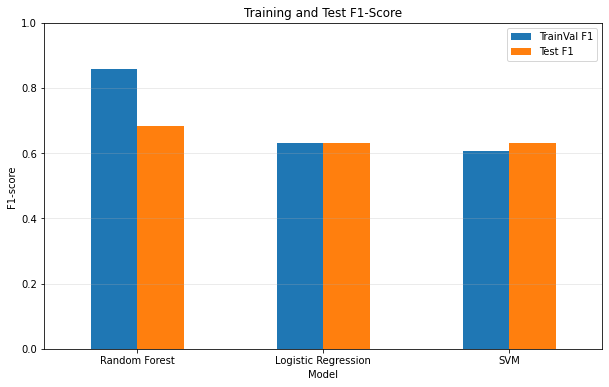

In [29]:
import matplotlib.pyplot as plt

plot_data = comparison_table.set_index("Model")

plot_data[
    ["TrainVal F1", "Test F1"]
].plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1)
)

plt.title("Training and Test F1-Score")
plt.ylabel("F1-score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

#### Plot training and test accuracy


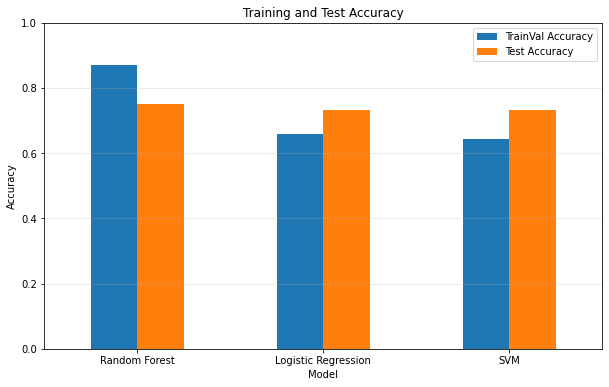

In [30]:
plot_data[
    ["TrainVal Accuracy", "Test Accuracy"]
].plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1)
)

plt.title("Training and Test Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

#### Print classification reports for all models on the untouched test set

In [31]:
from sklearn.metrics import classification_report

for model_name, model in best_models.items():

    test_predictions = model.predict(X_test)

    print(f"\n===== {model_name} =====")

    print(
        classification_report(
            y_test,
            test_predictions,
            target_names=["Fake", "Real"]
        )
    )


===== Logistic Regression =====
              precision    recall  f1-score   support

        Fake       0.65      1.00      0.79        26
        Real       1.00      0.46      0.63        26

    accuracy                           0.73        52
   macro avg       0.82      0.73      0.71        52
weighted avg       0.83      0.73      0.71        52


===== Random Forest =====
              precision    recall  f1-score   support

        Fake       0.68      0.96      0.79        26
        Real       0.93      0.54      0.68        26

    accuracy                           0.75        52
   macro avg       0.80      0.75      0.74        52
weighted avg       0.80      0.75      0.74        52


===== SVM =====
              precision    recall  f1-score   support

        Fake       0.65      1.00      0.79        26
        Real       1.00      0.46      0.63        26

    accuracy                           0.73        52
   macro avg       0.82      0.73      0.71        